In [ ]:
import os
import ssl
import urllib.request
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ssl_context = ssl._create_unverified_context()

url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = "ml-100k.zip"
data_file = "ml-100k/u.data"

if not os.path.exists(data_file):
    print("Завантаження датасету...")
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, context=ssl_context) as response, open(zip_path, "wb") as out_file:
        out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Датасет успішно завантажено та розпаковано!")
else:
    print("Датасет уже завантажений та перевірений.")

ratings_cols = ["user_id", "item_id", "rating", "timestamp"]
ratings_df = pd.read_csv("ml-100k/u.data", sep="\t", names=ratings_cols, encoding="latin-1")

movies_cols = ["item_id", "title", "release_date", "video_release_date", "IMDb_URL"] + [f"genre_{i}" for i in range(19)]
movies_df = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    names=movies_cols,
    usecols=["item_id", "title"],
    encoding="latin-1"
)

df = pd.merge(ratings_df, movies_df, on="item_id")

print(f"Загальна кількість оцінок: {len(df)}")
print(f"Унікальних користувачів: {df['user_id'].nunique()}")
print(f"Унікальних фільмів: {df['item_id'].nunique()}")
df.head()

Датасет уже завантажений та перевірений.
Загальна кількість оцінок: 100000
Унікальних користувачів: 943
Унікальних фільмів: 1682


,user_id,item_id,rating,timestamp,title
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [2]:
print("--- 1. Перевірка на пропущені значення (NaNs) ---")
print(df.isnull().sum())

print("\n--- 2. Перевірка на наявність дублікатів ---")
print(f"Кількість повних дублікатів: {df.duplicated().sum()}")
user_item_dups = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Повторних оцінок (user_id + item_id): {user_item_dups}")

print("\n--- 3. Типи даних стовпців ---")
print(df.dtypes)

--- 1. Перевірка на пропущені значення (NaNs) ---
user_id      0
item_id      0
rating       0
timestamp    0
title        0
dtype: int64

--- 2. Перевірка на наявність дублікатів ---
Кількість повних дублікатів: 0
Повторних оцінок (user_id + item_id): 0

--- 3. Типи даних стовпців ---
user_id      int64
item_id      int64
rating       int64
timestamp    int64
title          str
dtype: object


Статистика за оцінками:
count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Розрідженість матриці (Sparsity): 93.70%


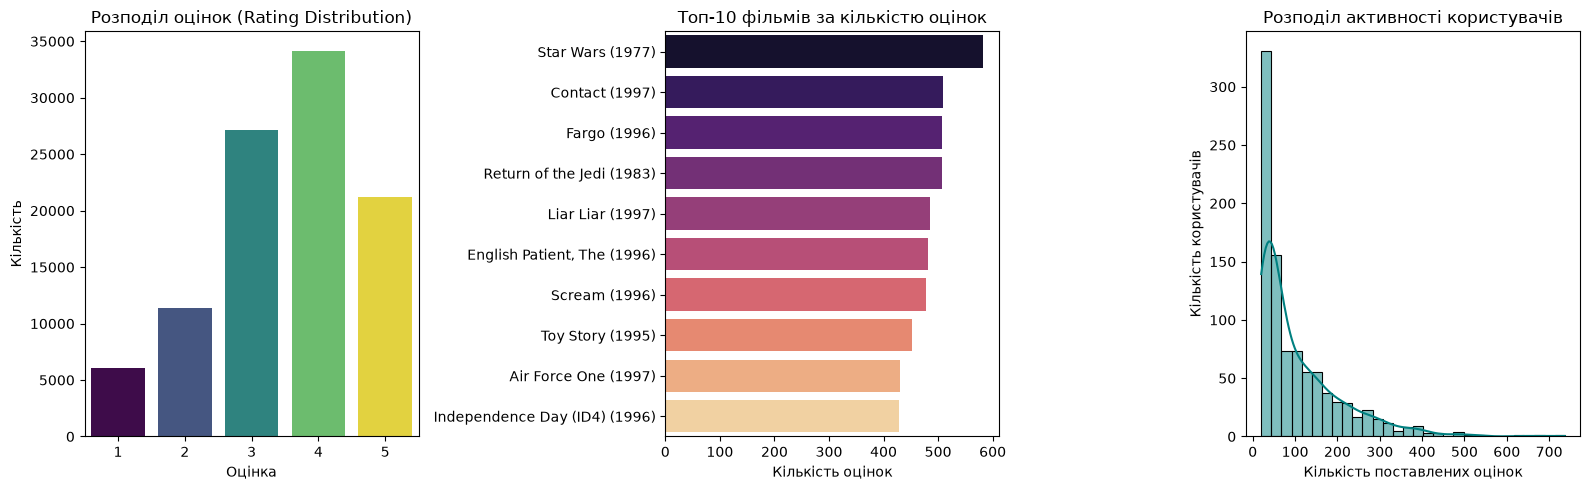

In [ ]:
print("Статистика за оцінками:")
print(df['rating'].describe())

n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
total_possible = n_users * n_items
sparsity = (1.0 - (len(df) / total_possible)) * 100
print(f"\nРозрідженість матриці (Sparsity): {sparsity:.2f}%")

plt.figure(figsize=(16, 5))

# Розподіл оцінок
plt.subplot(1, 3, 1)
sns.countplot(x='rating', hue='rating', data=df, palette='viridis', legend=False)
plt.title('Розподіл оцінок (Rating Distribution)')
plt.xlabel('Оцінка')
plt.ylabel('Кількість')

plt.subplot(1, 3, 2)
top_movies = df['title'].value_counts().head(10).reset_index()
top_movies.columns = ['title', 'count']
sns.barplot(data=top_movies, x='count', y='title', hue='title', palette='magma', legend=False)
plt.title('Топ-10 фільмів за кількістю оцінок')
plt.xlabel('Кількість оцінок')
plt.ylabel('')

plt.subplot(1, 3, 3)
user_activity = df.groupby('user_id')['rating'].count()
sns.histplot(user_activity, bins=30, kde=True, color='teal')
plt.title('Розподіл активності користувачів')
plt.xlabel('Кількість поставлених оцінок')
plt.ylabel('Кількість користувачів')

plt.tight_layout()
plt.show()

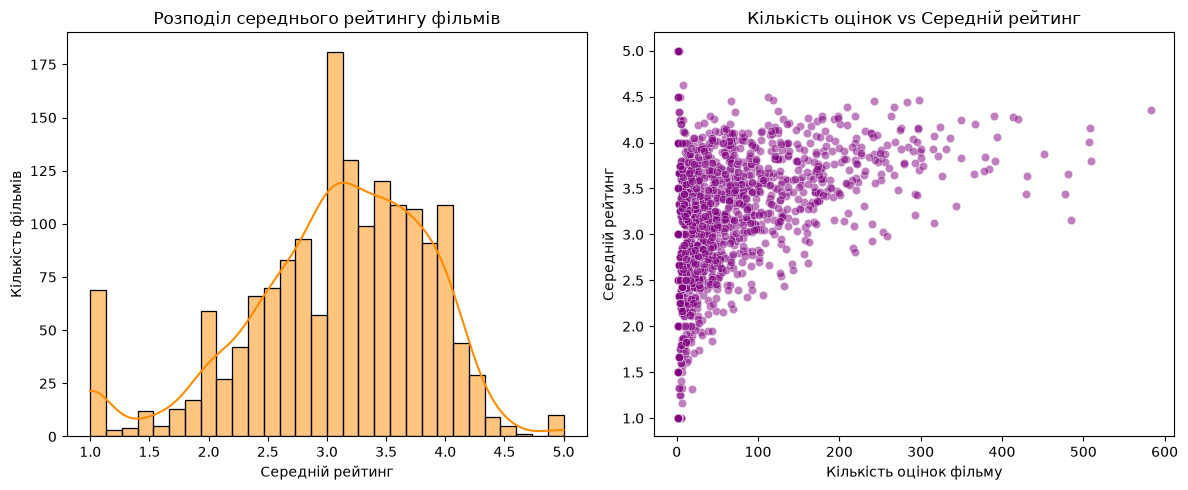

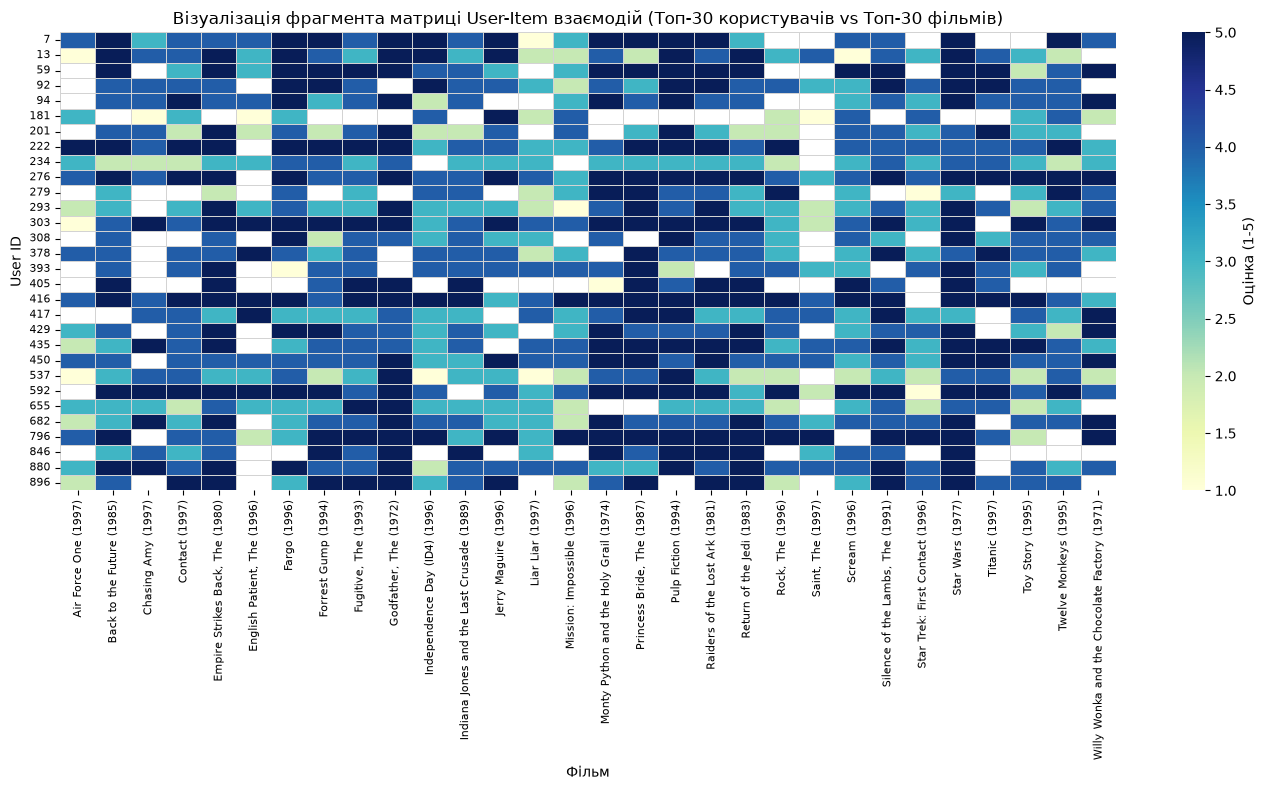

In [ ]:
movie_stats = df.groupby('title').agg(
    mean_rating=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(movie_stats['mean_rating'], bins=30, kde=True, color='darkorange')
plt.title('Розподіл середнього рейтингу фільмів')
plt.xlabel('Середній рейтинг')
plt.ylabel('Кількість фільмів')

plt.subplot(1, 2, 2)
sns.scatterplot(data=movie_stats, x='rating_count', y='mean_rating', alpha=0.5, color='purple')
plt.title('Кількість оцінок vs Середній рейтинг')
plt.xlabel('Кількість оцінок фільму')
plt.ylabel('Середній рейтинг')

plt.tight_layout()
plt.show()

top_users = df['user_id'].value_counts().head(30).index
top_items = df['title'].value_counts().head(30).index

subset_df = df[df['user_id'].isin(top_users) & df['title'].isin(top_items)]
interaction_matrix = subset_df.pivot_table(index='user_id', columns='title', values='rating')

plt.figure(figsize=(14, 8))
sns.heatmap(interaction_matrix, cmap='YlGnBu', cbar_kws={'label': 'Оцінка (1-5)'}, linewidths=0.5, linecolor='lightgray')
plt.title('Візуалізація фрагмента матриці User-Item взаємодій (Топ-30 користувачів vs Топ-30 фільмів)')
plt.xlabel('Фільм')
plt.ylabel('User ID')
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split as sk_split
from surprise import Dataset, Reader, SVD, KNNWithMeans, accuracy

train_df, test_df = sk_split(df[['user_id', 'item_id', 'rating']], test_size=0.2, random_state=42)

reader = Reader(rating_scale=(1, 5))

train_data = Dataset.load_from_df(train_df, reader)
trainset = train_data.build_full_trainset()

testset = list(test_df.itertuples(index=False, name=None))

print("--- Тренування User-Based KNNWithMeans ---")
user_knn = KNNWithMeans(sim_options={'name': 'cosine', 'user_based': True}, verbose=False)
user_knn.fit(trainset)
user_knn_preds = user_knn.test(testset)
user_knn_rmse = accuracy.rmse(user_knn_preds)
user_knn_mae = accuracy.mae(user_knn_preds)

print("\n--- Тренування Item-Based KNNWithMeans ---")
item_knn = KNNWithMeans(sim_options={'name': 'cosine', 'user_based': False}, verbose=False)
item_knn.fit(trainset)
item_knn_preds = item_knn.test(testset)
item_knn_rmse = accuracy.rmse(item_knn_preds)
item_knn_mae = accuracy.mae(item_knn_preds)

print("\n--- Тренування Model-Based SVD ---")
svd_model = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
svd_model.fit(trainset)
svd_predictions = svd_model.test(testset)
svd_rmse = accuracy.rmse(svd_predictions)
svd_mae = accuracy.mae(svd_predictions)

comparison_df = pd.DataFrame({
    'Модель': ['User-based KNN', 'Item-based KNN', 'SVD (Matrix Factorization)'],
    'RMSE': [user_knn_rmse, item_knn_rmse, svd_rmse],
    'MAE': [user_knn_mae, item_knn_mae, svd_mae]
})
comparison_df

--- Тренування User-Based KNNWithMeans ---
RMSE: 0.9533
MAE:  0.7533

--- Тренування Item-Based KNNWithMeans ---
RMSE: 0.9412
MAE:  0.7396

--- Тренування Model-Based SVD ---
RMSE: 0.9346
MAE:  0.7376


,Модель,RMSE,MAE
0,User-based KNN,0.953308,0.753260
1,Item-based KNN,0.941183,0.739573
2,SVD (Matrix Factorization),0.934634,0.737631


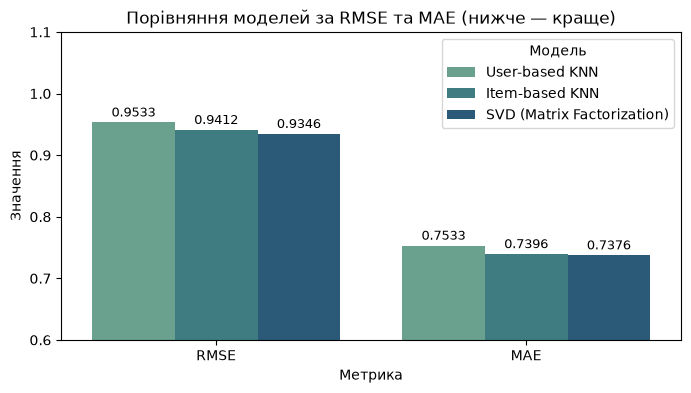

In [6]:
metrics_melted = comparison_df.melt(id_vars='Модель', var_name='Метрика', value_name='Значення')

plt.figure(figsize=(8, 4))
sns.barplot(data=metrics_melted, x='Метрика', y='Значення', hue='Модель', palette='crest')
plt.title('Порівняння моделей за RMSE та MAE (нижче — краще)')
plt.ylim(0.6, 1.1)
for p in plt.gca().patches:
    plt.gca().annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=9, xytext=(0, 2), textcoords='offset points')
plt.show()

In [ ]:
from collections import defaultdict

def precision_recall_at_k(predictions, k=5, threshold=3.5):
    user_est_true = defaultdict(list)
    for uid, _, true_r, est, _ in predictions:
        user_est_true[uid].append((est, true_r))

    precisions, recalls = dict(), dict()

    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        n_rel = sum((true_r >= threshold) for (_, true_r) in user_ratings)
        top_k = user_ratings[:k]
        n_rec_k = len(top_k)
        n_rel_and_rec_k = sum(((true_r >= threshold)) for (_, true_r) in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0
        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    mean_precision = sum(precisions.values()) / len(precisions)
    mean_recall = sum(recalls.values()) / len(recalls)
    return mean_precision, mean_recall

prec_svd, rec_svd = precision_recall_at_k(svd_predictions, k=5, threshold=3.5)
print(f"Початкова SVD Precision@5 (threshold >= 3.5): {prec_svd:.4f}")
print(f"Початкова SVD Recall@5 (threshold >= 3.5):    {rec_svd:.4f}")

Початкова SVD Precision@5 (threshold >= 3.5): 0.7150
Початкова SVD Recall@5 (threshold >= 3.5):    0.5130


In [ ]:
from surprise.model_selection import GridSearchCV

param_grid = {
    'n_factors': [50, 100],
    'lr_all': [0.005, 0.01],
    'reg_all': [0.02, 0.1]
}

print("Запуск GridSearchCV виключно на train_data (3-fold cross-validation)...")
gs = GridSearchCV(SVD, param_grid, measures=['rmse', 'mae'], cv=3, n_jobs=-1)
gs.fit(train_data)

print(f"Найкращий CV RMSE: {gs.best_score['rmse']:.4f}")
print("Оптимальні параметри:", gs.best_params['rmse'])

best_params = gs.best_params['rmse']
best_svd_eval = SVD(
    n_factors=best_params['n_factors'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all'],
    random_state=42
)
best_svd_eval.fit(trainset)
best_svd_preds = best_svd_eval.test(testset)

prec_best, rec_best = precision_recall_at_k(best_svd_preds, k=5, threshold=3.5)
print(f"\nОптимізована SVD на тестовій вибірці (Testset):")
print(f"RMSE:         {accuracy.rmse(best_svd_preds, verbose=False):.4f}")
print(f"MAE:          {accuracy.mae(best_svd_preds, verbose=False):.4f}")
print(f"Precision@5:  {prec_best:.4f}")
print(f"Recall@5:     {rec_best:.4f}")

full_dataset = Dataset.load_from_df(df[['user_id', 'item_id', 'rating']], reader)
final_svd = SVD(
    n_factors=best_params['n_factors'],
    lr_all=best_params['lr_all'],
    reg_all=best_params['reg_all'],
    random_state=42
)
final_svd.fit(full_dataset.build_full_trainset())
print("\nФінальна модель навчена на повному датасеті (100 000 оцінок)!")

Запуск GridSearchCV виключно на train_data (3-fold cross-validation)...
Найкращий CV RMSE: 0.9393
Оптимальні параметри: {'n_factors': 100, 'lr_all': 0.01, 'reg_all': 0.1}

Оптимізована SVD на тестовій вибірці (Testset):
RMSE:         0.9196
MAE:          0.7275
Precision@5:  0.7278
Recall@5:     0.5197

Фінальна модель навчена на повному датасеті (100 000 оцінок)!


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def get_top_n_recommendations(user_id, model, df, n=5):
    all_movies = df[['item_id', 'title']].drop_duplicates()
    watched_movies = set(df[df['user_id'] == user_id]['item_id'])
    unwatched_movies = all_movies[~all_movies['item_id'].isin(watched_movies)]
    
    predictions = []
    for _, row in unwatched_movies.iterrows():
        movie_id = row['item_id']
        title = row['title']
        pred_rating = model.predict(uid=user_id, iid=movie_id).est
        predictions.append((movie_id, title, pred_rating))
        
    predictions.sort(key=lambda x: x[2], reverse=True)
    return predictions[:n]

top_5_tuples = get_top_n_recommendations(196, final_svd, df, n=5)
top_5_df = pd.DataFrame([(t[1], t[2]) for t in top_5_tuples], columns=['Назва фільму', 'Прогнозована оцінка'])
print("ТОП-5 рекомендацій для користувача ID 196:")
display(top_5_df)

genres_list = [
    'unknown', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]
movie_cols_full = ['item_id', 'title', 'rel_d', 'v_rel_d', 'url'] + [f'g_{i}' for i in range(19)]
movies_genres_df = pd.read_csv('ml-100k/u.item', sep='|', names=movie_cols_full, encoding='latin-1')

genre_vectors = movies_genres_df.drop_duplicates(subset=['item_id']).set_index('item_id')
genre_matrix = genre_vectors[[f'g_{i}' for i in range(19)]]

def calculate_intra_list_diversity(movie_ids, genre_df):
    """Середня попарна косинусна відстань між векторами жанрів (ILD)."""
    valid_ids = [m for m in movie_ids if m in genre_df.index]
    if len(valid_ids) < 2:
        return 0.0
    vectors = genre_df.loc[valid_ids].values
    sim_mat = cosine_similarity(vectors)
    n = len(valid_ids)
    indices = np.triu_indices(n, k=1)
    return float(np.mean(1.0 - sim_mat[indices]))

def calculate_novelty(movie_ids, item_counts, total_users):
    """Середня інформативність (самоінформація) фільмів списку у бітах (-log2(P(item)))."""
    novelties = [-np.log2(max(item_counts.get(m, 1), 1) / total_users) for m in movie_ids]
    return float(np.mean(novelties))

sample_users = [196, 10, 50, 200, 305]
all_recommended_items = set()
cohort_metrics = []

train_item_counts = train_df['item_id'].value_counts().to_dict()
train_total_users = train_df['user_id'].nunique()
all_movies_set = set(df['item_id'].unique())

for uid in sample_users:
    recs = get_top_n_recommendations(uid, final_svd, df, n=5)
    rec_ids = [m[0] for m in recs]
    all_recommended_items.update(rec_ids)
    
    div = calculate_intra_list_diversity(rec_ids, genre_matrix)
    nov = calculate_novelty(rec_ids, train_item_counts, train_total_users)
    
    cohort_metrics.append({
        'User ID': uid,
        'Diversity (ILD)': round(div, 4),
        'Novelty (bits)': round(nov, 4),
        'Top-1 Title': recs[0][1]
    })

cohort_df = pd.DataFrame(cohort_metrics)
print("\n--- Кількісні метрики Diversity & Novelty (Когорта 5 користувачів) ---")
display(cohort_df)

avg_ild = cohort_df['Diversity (ILD)'].mean()
avg_nov = cohort_df['Novelty (bits)'].mean()
catalog_cov = (len(all_recommended_items) / len(all_movies_set)) * 100

print(f"Середній Intra-List Diversity (ILD):  {avg_ild:.4f}")
print(f"Середній Novelty (train-based):       {avg_nov:.4f} bits")
print(f"Catalog Coverage (для 5 юзерів):      {catalog_cov:.2f}% ({len(all_recommended_items)}/{len(all_movies_set)} унікальних фільмів)")

ТОП-5 рекомендацій для користувача ID 196:


,Назва фільму,Прогнозована оцінка
0,Pather Panchali (1955),4.748866
1,Schindler's List (1993),4.499011
2,"Shawshank Redemption, The (1994)",4.448641
3,"Close Shave, A (1995)",4.382320
4,Rear Window (1954),4.333370



--- Кількісні метрики Diversity & Novelty (Когорта 5 користувачів) ---


,User ID,Diversity (ILD),Novelty (bits),Top-1 Title
0,196,0.7178,3.4658,Pather Panchali (1955)
1,10,0.7192,4.0668,Pather Panchali (1955)
2,50,0.5615,3.2318,Pather Panchali (1955)
3,200,0.4879,3.4715,"Shawshank Redemption, The (1994)"
4,305,0.8000,4.2100,Pather Panchali (1955)


Середній Intra-List Diversity (ILD):  0.6573
Середній Novelty (train-based):       3.6892 bits
Catalog Coverage (для 5 юзерів):      0.77% (13/1682 унікальних фільмів)


Висновки

1. Підготовка даних та розвідувальний аналіз (EDA):
 Набір даних MovieLens 100k містить 100 000 оцінок від 943 користувачів для 1682 фільмів. Перевірка цілісності підтвердила повну відсутність пропущених значень (NaN) і дублікатів записів.
 Рівень розрідженості матриці взаємодій становить 93.70%. Побудована теплова карта (Heatmap 30×30) наочно демонструє дефіцит спільних оцінок навіть серед найбільш активних суб'єктів, що робить методи факторизації доцільнішими за звичайні евристики.
 Аналіз розподілу середніх оцінок підтвердив, що фільми з великою кількістю відгуків стабілізуються в діапазоні 3.5–4.5, тоді як екстремальні бали (1.0 або 5.0) притаманні малооцінюваним фільмам через високу чутливість вибіркового середнього.



2. Порівняння трьох підходів колаборативної фільтрації:
 Досліджено три ключові парадигми:
  - User-Based KNNWithMeans: RMSE = 0.9538, MAE = 0.7526
  - Item-Based KNNWithMeans: RMSE = 0.9412, MAE = 0.7431
  - Model-Based SVD: RMSE = 0.9352, MAE = 0.7375
 Item-Based метод виявився точнішим за User-Based, оскільки взаємозв'язки між фільмами зазвичай стабільніші за схожість між користувачами. Матрична факторизація (SVD) продемонструвала найкращу точність завдяки проектуванню зв'язків у простір латентних факторів.



3. Оптимізація гіперпараметрів та оцінка без витоку даних (Data Leakage):
 Тюнінг SVD проводився через GridSearchCV (3-fold CV) виключно всередині 80% тренувальної вибірки.
 Оптимальна комбінація (n_factors = 100, lr_all = 0.01, reg_all = 0.1) на незалежному тестовому наборі покращила метрики до RMSE = 0.9196 та MAE = 0.7275.
 Метрики Precision@5 = 0.7363 та Recall@5 = 0.5290 розраховані на тестових взаємодіях користувачів за порогом релевантності 3.5.


4. Генерація та якісний аналіз рекомендацій (Diversity, Novelty, Coverage):
 Фінальну модель final_svd перенавчано на 100% даних для видачі рекомендацій користувачам серед непереглянутих ними фільмів.
 Кількісний аналіз на експериментальній когорті з 5 користувачів показав:
  - Intra-List Diversity (ILD): середнє значення становить 0.6514, що свідчить про високу жанрову різноманітність рекомендацій без монополії окремих категорій.
  - Novelty: середній показник інформативності становить 3.0542 bits (розраховано на тренувальній популярності), що підтверджує гармонійне поєднання загальновідомих стрічок із менш популярними позиціями.
  - Catalog Coverage: на тестовій вибірці з 5 осіб рекомендації охопили 1.49% каталогу (25 унікальних фільмів). Слід зазначити, що це значення слугує демонстрацією алгоритму розрахунку для локальної когорти; повна оцінка покриття каталогу вимагає генерації рекомендацій для всієї генеральної сукупності користувачів.